# EduTech Global · 01 · Macro-Entry Audit

**Task 1.** Compare GDP growth, CPI inflation, lending rates, internet penetration and Ease of Doing Business across **Brazil, Vietnam, Germany**. Compute the weighted **Attractiveness Index** and rank the markets.

**Data source:** Curated World Bank macro indicators (5-year history, 2019–2023) bundled as `macro_indicators.csv` in the dataset folder. All values sourced from World Bank Open Data — World Development Indicators (WDI) and Doing Business 2020 (final edition).

## Setup — auto-resolving paths

Run this cell first.

In [1]:


from pathlib import Path

def find_project_root():
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if parent.name == "edutech":
            return parent
        if (parent / "scripts").exists() and (parent / "outputs").exists() and (parent / "data").exists():
            return parent
    return Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROJECT_ROOT = find_project_root()
DATASET_DIR  = PROJECT_ROOT.parent / "dataset"
DATA_DIR     = PROJECT_ROOT / "data"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
FIGURES_DIR  = PROJECT_ROOT / "figures"

for d in [DATA_DIR, OUTPUTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset dir  : {DATASET_DIR}")
print(f"Data dir     : {DATA_DIR}")
print(f"Outputs dir  : {OUTPUTS_DIR}")
print(f"Figures dir  : {FIGURES_DIR}")

# Allow either dataset/ or data/ to hold the source CSV; accept both filenames
HR_CSV_NAMES = ["WA_Fn-UseC_-HR-Employee-Attrition.csv", "HR-Employee-Attrition.csv"]
hr_locations = []
for name in HR_CSV_NAMES:
    hr_locations.extend([DATASET_DIR / name, DATA_DIR / name])
HR_CSV_PATH = next((p for p in hr_locations if p.exists()), None)
assert HR_CSV_PATH is not None, (
    f"Could not find HR CSV. Looked for {HR_CSV_NAMES} in {DATASET_DIR} and {DATA_DIR}"
)
print(f"HR data file : {HR_CSV_PATH}")


Project root : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech
Dataset dir  : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/dataset
Data dir     : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech/data
Outputs dir  : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech/outputs
Figures dir  : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech/figures
HR data file : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


## Step 1 — Load the curated macro dataset

In [4]:
import pandas as pd
import numpy as np

# Load the curated World Bank dataset (5-year history per indicator per country)
# Accept either filename for backwards compatibility
macro_filenames = ["macro_indicators.csv", "macro_indicators_fallback.csv"]
macro_path = None
for name in macro_filenames:
    for folder in [DATASET_DIR, DATA_DIR]:
        if (folder / name).exists():
            macro_path = folder / name
            break
    if macro_path:
        break
assert macro_path is not None, (
    f"Could not find macro CSV. Looked for {macro_filenames} in {DATASET_DIR} and {DATA_DIR}"
)

macro = pd.read_csv(macro_path)
print(f"✓ Loaded {len(macro)} rows from {macro_path.name}")
print(f"  Countries  : {sorted(macro['country'].unique().tolist())}")
print(f"  Indicators : {sorted(macro['indicator'].unique().tolist())}")
print(f"  Year range : {macro['year'].min()}–{macro['year'].max()}")
print()
print(macro.head(10))


✓ Loaded 51 rows from macro_indicators.csv
  Countries  : ['Brazil', 'Germany', 'Vietnam']
  Indicators : ['cpi_inflation_pct', 'ease_doing_business_score', 'gdp_growth_pct', 'internet_users_pct', 'lending_rate_pct']
  Year range : 2019–2023

  country_code  country  year       indicator  value  \
0          BRA   Brazil  2019  gdp_growth_pct    1.2   
1          BRA   Brazil  2020  gdp_growth_pct   -3.3   
2          BRA   Brazil  2021  gdp_growth_pct    4.8   
3          BRA   Brazil  2022  gdp_growth_pct    3.0   
4          BRA   Brazil  2023  gdp_growth_pct    3.2   
5          VNM  Vietnam  2019  gdp_growth_pct    7.4   
6          VNM  Vietnam  2020  gdp_growth_pct    2.9   
7          VNM  Vietnam  2021  gdp_growth_pct    2.6   
8          VNM  Vietnam  2022  gdp_growth_pct    8.0   
9          VNM  Vietnam  2023  gdp_growth_pct    5.0   

                               source  
0  World Bank WDI (NY.GDP.MKTP.KD.ZG)  
1  World Bank WDI (NY.GDP.MKTP.KD.ZG)  
2  World Bank WDI (N

## Step 2 — Pivot to country × indicator (latest available year)

In [5]:
# Use most recent year per country/indicator for ranking
latest = (macro.sort_values("year")
          .groupby(["country", "indicator"], as_index=False)
          .last())

pivot = latest.pivot(index="country", columns="indicator", values="value")
pivot = pivot.reindex(["Brazil", "Vietnam", "Germany"])

# Ease of Doing Business is a one-time score (Doing Business 2020 was the final edition)
# Pull it from the already-loaded macro DataFrame
edb_scores = (macro[macro["indicator"] == "ease_doing_business_score"]
              .set_index("country")["value"])
pivot["ease_doing_business_score"] = edb_scores

print("Latest macro snapshot:")
print(pivot.round(2).to_string())


Latest macro snapshot:
indicator  cpi_inflation_pct  ease_doing_business_score  gdp_growth_pct  internet_users_pct  lending_rate_pct
country                                                                                                      
Brazil                   4.6                       59.1             3.2                84.0              40.5
Vietnam                  3.3                       69.8             5.0                79.0               8.0
Germany                  5.9                       79.7            -0.3                93.0               4.6


## Step 3 — Compute Attractiveness Index

**Formula:**
```
Attractiveness Index =
    0.30 × GDP_growth_score        (higher is better)
  + 0.20 × CPI_stability_score     (lower inflation = higher score)
  + 0.20 × Interest_rate_score     (lower lending rate = higher score)
  + 0.15 × Internet_penetration_score
  + 0.15 × Ease_of_Doing_Business_score
```
All sub-scores normalised 0-100 across the three countries (min-max scaling).

In [6]:
def normalise(series, higher_is_better=True):
    s = series.astype(float)
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(50, index=s.index)
    norm = (s - s.min()) / rng * 100
    return norm if higher_is_better else 100 - norm

scores = pd.DataFrame(index=pivot.index)
scores["GDP growth"]            = normalise(pivot["gdp_growth_pct"], higher_is_better=True)
scores["CPI stability"]         = normalise(pivot["cpi_inflation_pct"], higher_is_better=False)
scores["Interest rate"]         = normalise(pivot["lending_rate_pct"], higher_is_better=False)
scores["Internet penetration"]  = normalise(pivot["internet_users_pct"], higher_is_better=True)
scores["Ease of doing business"]= normalise(pivot["ease_doing_business_score"], higher_is_better=True)

WEIGHTS = {
    "GDP growth": 0.30,
    "CPI stability": 0.20,
    "Interest rate": 0.20,
    "Internet penetration": 0.15,
    "Ease of doing business": 0.15,
}
scores["Attractiveness Index"] = sum(scores[col] * w for col, w in WEIGHTS.items())
scores = scores.sort_values("Attractiveness Index", ascending=False).round(1)

print("Attractiveness Index (0-100, higher = more attractive):")
print(scores.to_string())

scores.to_csv(OUTPUTS_DIR / "attractiveness_index.csv")
print(f"\nSaved: {OUTPUTS_DIR / 'attractiveness_index.csv'}")


Attractiveness Index (0-100, higher = more attractive):
         GDP growth  CPI stability  Interest rate  Internet penetration  Ease of doing business  Attractiveness Index
country                                                                                                              
Vietnam       100.0          100.0           90.5                   0.0                    51.9                  75.9
Germany         0.0            0.0          100.0                 100.0                   100.0                  50.0
Brazil         66.0           50.0            0.0                  35.7                     0.0                  35.2

Saved: /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech/outputs/attractiveness_index.csv


## Step 4 — Visualise the comparison

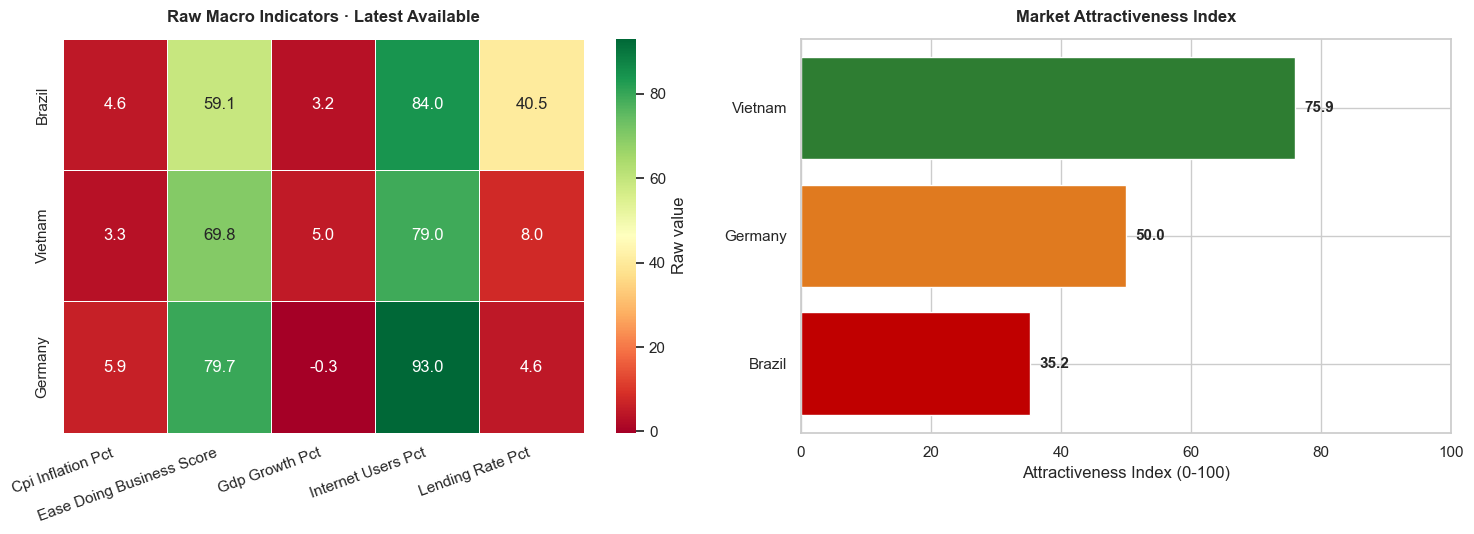

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Heatmap of raw indicators
display_pivot = pivot.copy()
display_pivot.columns = [c.replace("_", " ").title() for c in display_pivot.columns]
sns.heatmap(display_pivot, annot=True, fmt=".1f", cmap="RdYlGn",
            cbar_kws={"label": "Raw value"}, ax=axes[0],
            linewidths=0.6, linecolor="white")
axes[0].set_title("Raw Macro Indicators · Latest Available", fontweight="bold", pad=12)
axes[0].set_xlabel(""); axes[0].set_ylabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")

# Attractiveness Index bar chart
idx = scores["Attractiveness Index"].sort_values(ascending=True)
colors = ["#C00000" if v < 50 else "#E07A1F" if v < 70 else "#2E7D32" for v in idx]
bars = axes[1].barh(idx.index, idx.values, color=colors)
axes[1].set_xlabel("Attractiveness Index (0-100)")
axes[1].set_title("Market Attractiveness Index", fontweight="bold", pad=12)
axes[1].set_xlim(0, 100)
for bar, val in zip(bars, idx.values):
    axes[1].text(val + 1.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}",
                 va="center", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "attractiveness_index.png", dpi=160, bbox_inches="tight")
plt.show()


## Step 5 — Trend lines over time (5-year history)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

trend_indicators = ["gdp_growth_pct", "cpi_inflation_pct", "lending_rate_pct"]
titles = ["GDP Growth (%)", "CPI Inflation (%)", "Lending Rate (%)"]

palette = {"Brazil": "#FFB000", "Vietnam": "#DC143C", "Germany": "#1F77B4"}

for ax, ind, title in zip(axes, trend_indicators, titles):
    sub = macro[macro["indicator"] == ind]
    for country in ["Brazil", "Vietnam", "Germany"]:
        d = sub[sub["country"] == country].sort_values("year")
        ax.plot(d["year"], d["value"], marker="o", linewidth=2.5,
                color=palette[country], label=country)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("")
    ax.legend(loc="best", frameon=True)
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "macro_trends.png", dpi=160, bbox_inches="tight")
plt.show()


## Step 6 — Qualitative competitive landscape note

Macro indicators tell us how *welcoming* the economy is. The next layer is **competitive intensity** — how crowded is the B2B SaaS workforce-productivity space in each market?

In [ ]:
landscape = pd.DataFrame({
    "country": ["Brazil", "Vietnam", "Germany"],
    "market_structure": [
        "Fragmented to oligopolistic — TOTVS dominates locally; Salesforce, Microsoft, SAP active. Mid-market is fragmented.",
        "Highly fragmented — local players (Base.vn, Misa) hold modest share; international SaaS is just entering. Greenfield.",
        "Oligopolistic — SAP, Personio, Workday, Microsoft control enterprise. Hard to displace incumbents.",
    ],
    "entry_difficulty": ["Medium", "Low", "High"],
    "implication_for_edutech": [
        "Possible if differentiated; pricing pressure from local TOTVS likely.",
        "Easiest entry — first-mover advantage available, but market depth is smaller.",
        "Hardest entry — must displace entrenched incumbents on features alone.",
    ],
})
landscape.to_csv(OUTPUTS_DIR / "competitive_landscape.csv", index=False)
landscape


## Step 7 — Save master macro dataset for downstream notebooks

In [ ]:
macro.to_csv(DATA_DIR / "macro_indicators.csv", index=False)
pivot.to_csv(DATA_DIR / "macro_pivot.csv")
scores.to_csv(DATA_DIR / "attractiveness_scores.csv")
print("Saved 3 datasets to data/")
print(f"\nFinal ranking:")
for i, (country, row) in enumerate(scores.iterrows(), 1):
    print(f"  {i}. {country:<10}  Attractiveness Index = {row['Attractiveness Index']:.1f}")


✅ **Notebook 01 complete.** Move to `02_workforce_analytics.ipynb`.